In [ ]:
##Required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

sns.set(style="whitegrid")
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Import drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Checking list of uploaded files in MyDrive
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'Classroom', 'Doc Scanner', 'Doc Scanner Upload', 'Write a program in python of related to Tower of H....gdoc', 'COI Rollno_403 (1).pdf', 'COI Rollno_403.pdf', 'Rollno_403-Disk_Storage(IIT-02).pptx', 'Rollno_403 IIT_02 (CFG_and_DerTree) (2).pptx', 'Rollno_403 IIT_02 (CFG_and_DerTree) (1).pptx', 'Rollno_403 IIT_02 (CFG_and_DerTree).pptx', 'Rollno_403_InputOutput-Devices-& Interfaces_IIT-02.pptx', 'Ishu Contact.jpg', 'ISHU CONTACT Number.jpg', 'VID_20250511_100334_942.mp4', 'Screenshot_20250513_135747.jpg', 'Screenshot_20250513_135724.jpg', 'Screenshot_20250513_135741.jpg', 'Data Science Colab Notebooks', 'OBJECT ORIENTED PROGRAMMING THROUGH JAVA NOTES (2).gdoc', 'OBJECT ORIENTED PROGRAMMING THROUGH JAVA NOTES (1).gdoc', 'IMG-20250823-WA0010.jpg', 'PS_01_RollNo_403_DBMS_Himanshu_Gupta.pdf', 'PS_01_RollNo_403_Signal&System_Himanshu Gupta.pdf', "PS_01_OOP's_Rollno_403_Himanshu.pdf", 'PS_02_Rollno_403_Himanshu_Gupta_OOPs_ (2).pdf', 'PS_02_Rollno_403_Himanshu_Gupta_OOPs_ 

In [ ]:
#Reading the raw data
df = pd.read_csv("/content/drive/MyDrive/amazon_review_dataset.csv")
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [ ]:
df.shape

(1597, 27)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [ ]:
df.describe()

,ean,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince,sizes,upc
count,8.980000e+02,900.000000,1177.000000,0.0,0.0,0.0,8.980000e+02
mean,8.443135e+11,83.584444,4.359388,NaN,NaN,NaN,8.443135e+11
std,3.416444e+09,197.150238,1.021445,NaN,NaN,NaN,3.416444e+09
min,8.416670e+11,0.000000,1.000000,NaN,NaN,NaN,8.416670e+11
25%,8.416670e+11,0.000000,4.000000,NaN,NaN,NaN,8.416670e+11
50%,8.416670e+11,0.000000,5.000000,NaN,NaN,NaN,8.416670e+11
75%,8.487190e+11,34.000000,5.000000,NaN,NaN,NaN,8.487190e+11
max,8.487190e+11,997.000000,5.000000,NaN,NaN,NaN,8.487190e+11


In [ ]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

In [ ]:
## Checking missing value
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,823
dateAdded,0
dateUpdated,0
dimension,1032
ean,699
keys,0


In [ ]:
##dropping missing review rating
df = df.dropna(subset=["reviews.rating"])
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,508
dateAdded,0
dateUpdated,0
dimension,620
ean,484
keys,0


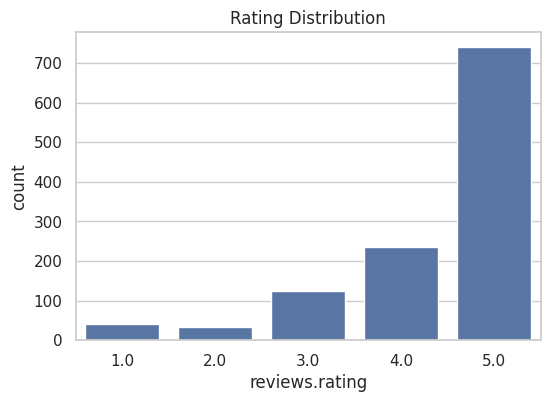

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="reviews.rating", data=df)
plt.title("Rating Distribution")
plt.show()

In [ ]:
df = df[["reviews.text", "reviews.rating"]]


In [ ]:
df

,reviews.text,reviews.rating
0,I initially had trouble deciding between the p...,5.0
1,Allow me to preface this with a little history...,5.0
2,I am enjoying it so far. Great for reading. Ha...,4.0
3,I bought one of the first Paperwhites and have...,5.0
4,I have to say upfront - I don't like coroporat...,5.0
...,...,...
1592,This is not the same remote that I got for my ...,3.0
1593,I have had to change the batteries in this rem...,1.0
1594,"Remote did not activate, nor did it connect to...",1.0
1595,It does the job but is super over priced. I fe...,3.0


In [ ]:
df.shape

(1177, 2)

In [ ]:
##defining a function for converting in sentiment label
def label_sentiment(rating):
    if rating >= 4:
        return 1   # Positive
    elif rating <= 2:
        return 0   # Negative
    else:
        return None  # Neutral (we drop these)

df["sentiment"] = df["reviews.rating"].apply(label_sentiment)

In [ ]:
##Remove neutral review
df = df.dropna(subset=["sentiment"])
df["sentiment"].value_counts()

,count
sentiment,
1.0,977
0.0,76


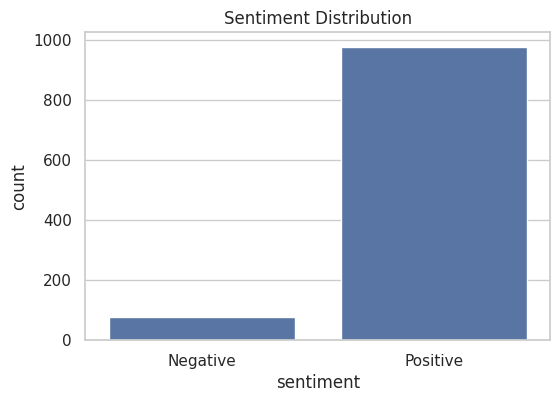

In [ ]:
##Analyzing Sentiment Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
##REview Length analysis
df["review_length"] = df["reviews.text"].apply(len)
df["review_length"].describe()

/tmp/ipython-input-132644765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["review_length"] = df["reviews.text"].apply(len)


,review_length
count,1053.000000
mean,697.446344
std,1307.149798
min,3.000000
25%,106.000000
50%,262.000000
75%,1343.000000
max,19739.000000


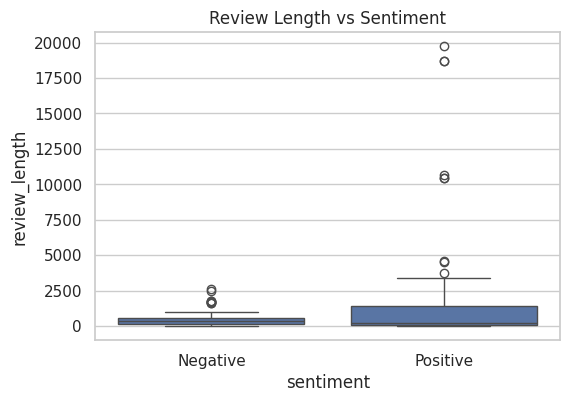

In [ ]:
## Analyzing REview length vs Sentiment
plt.figure(figsize=(6,4))
sns.boxplot(x="sentiment", y="review_length", data=df)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Review Length vs Sentiment")
plt.show()

In [ ]:
##Define a function for cleaning text
def clean_text(text):
  text=str(text).lower()
  text = re.sub(r"http\S+", "", text)      # remove URLs
  text = re.sub(r"[^a-z\s]", "", text)     # keep only letters
  text = re.sub(r"\s+", " ", text).strip() # extra spaces
  words = text.split()
  words = [w for w in words if w not in stop_words]  # remove stopwords

  return " ".join(words)


df["Cleaned_Review"]=df["reviews.text"].apply(clean_text)
df = df.dropna(subset=["Cleaned_Review"])
df = df.dropna(subset=["Cleaned_Review"])
df = df[df["Cleaned_Review"].str.strip() != ""]

/tmp/ipython-input-2463020994.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Cleaned_Review"]=df["reviews.text"].apply(clean_text)


In [ ]:
df.head()

,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,initially trouble deciding paperwhite voyage r...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow preface little history casual reader own...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,enjoying far great reading original fire since...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,bought one first paperwhites pleased constant ...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,say upfront dont like coroporate hermetically ...


In [ ]:
df.shape

(1052, 5)

###  Positive box is higher and wider so it means people usally write more when giving positive feedback and while Most negative reviews are concentrated near the bottom so suggests people often write short complaints

In [ ]:
df["reviews.text"][0]

"I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both models now have 300 ppi, so the 80 dollar jump turns out pricey the voyage's page press isn't always sensitive, and if you are fine with a specific setting, you don't need auto light adjustment).It's been a week and I am loving my paperwhite, no regrets! The touch screen is receptive and easy to use, and I keep the light at a specific setting regardless of the time of day. (In any case, it's not hard to change the setting either, as you'll only be changing the light level at a certain time of day, not every now and then while reading).Also glad that I went for the international shipping option with Amazon. Extra expense, but delivery was on time, with tracking, and I didnt need to worry about cu

In [ ]:
df["Cleaned_Review"][0]

'initially trouble deciding paperwhite voyage reviews less said thing paperwhite great spending money go voyagefortunately friends owned ended buying paperwhite basis models ppi dollar jump turns pricey voyages page press isnt always sensitive fine specific setting dont need auto light adjustmentits week loving paperwhite regrets touch screen receptive easy use keep light specific setting regardless time day case hard change setting either youll changing light level certain time day every readingalso glad went international shipping option amazon extra expense delivery time tracking didnt need worry customs may used third party shipping service'

In [ ]:
import os

project_path = "/content/drive/MyDrive/amazon_review_project/data"
os.makedirs(project_path, exist_ok=True)


In [ ]:
## Save a cleaned data into MyDrive
df.to_csv(
    "/content/drive/MyDrive/amazon_review_project/data/clean_amazon_reviews.csv",
    index=False
)

### Feature Engineering

In [ ]:
## Reading Cleaned data
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/amazon_review_project/data/clean_amazon_reviews.csv"
)

df.head()


,reviews.text,reviews.rating,sentiment,review_length,Cleaned_Review
0,I initially had trouble deciding between the p...,5.0,1.0,1064,initially trouble deciding paperwhite voyage r...
1,Allow me to preface this with a little history...,5.0,1.0,1424,allow preface little history casual reader own...
2,I am enjoying it so far. Great for reading. Ha...,4.0,1.0,182,enjoying far great reading original fire since...
3,I bought one of the first Paperwhites and have...,5.0,1.0,1671,bought one first paperwhites pleased constant ...
4,I have to say upfront - I don't like coroporat...,5.0,1.0,1916,say upfront dont like coroporate hermetically ...


In [ ]:
##Selecting Input Column and Output Column
X=df["Cleaned_Review"]
y=df["sentiment"]

In [ ]:
X

,Cleaned_Review
0,initially trouble deciding paperwhite voyage r...
1,allow preface little history casual reader own...
2,enjoying far great reading original fire since...
3,bought one first paperwhites pleased constant ...
4,say upfront dont like coroporate hermetically ...
...,...
1047,voice remote gave nearly year purchased change...
1048,purchased first one tv fire box year ago gone ...
1049,change batteries remote twice per month since ...
1050,remote activate connect boxa poorly designed r...


In [ ]:
y

,sentiment
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
1047,0.0
1048,0.0
1049,0.0
1050,0.0


In [ ]:
##Splitting data into training and testing
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
##Converting text into number using TF-IDF to understand for ML model
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer(max_features=2500,ngram_range=(1,2))

X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)

In [ ]:
## Training a model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_vec, y_train)

LogisticRegression()

In [ ]:
## Evaluting a model
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9478672985781991
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        11
         1.0       0.95      1.00      0.97       200

    accuracy                           0.95       211
   macro avg       0.47      0.50      0.49       211
weighted avg       0.90      0.95      0.92       211



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
##Hyperparameter Tunning using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000))
])
param_grid = {
    "tfidf__max_features": [2000, 3000, 5000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [3, 5],
    "tfidf__max_df": [0.9, 0.95],

    "clf__C": [0.1, 1, 10],
    "clf__solver": ["liblinear"],
    "clf__class_weight": ["balanced"]
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",    #Best metric for NLP
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train,y_train)

print("Best Parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__solver': 'liblinear', 'tfidf__max_df': 0.9, 'tfidf__max_features': 3000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}


#### “I used GridSearchCV with a pipeline to tune TF-IDF and Logistic Regression hyperparameters using F1-score, which is suitable for imbalanced sentiment datasets.

In [ ]:
TfidfVectorizer()
LogisticRegression()

In [ ]:
##Converting text into number using TF-IDF to understand for ML model using GridSearchCV Hyperparameter Tunning best parameter
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=3, max_df=0.9)

X_train_vec=vectorizer.fit_transform(X_train)
X_test_vec=vectorizer.transform(X_test)

In [ ]:
## Training a model using GridSearchCV Hyperparameter Tunning best parameter
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=10, solver="liblinear", class_weight="balanced")
model.fit(X_train_vec, y_train)

LogisticRegression(C=10, class_weight='balanced', solver='liblinear')

In [ ]:
## Evaluting a model
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.933649289099526
              precision    recall  f1-score   support

         0.0       0.33      0.27      0.30        11
         1.0       0.96      0.97      0.97       200

    accuracy                           0.93       211
   macro avg       0.65      0.62      0.63       211
weighted avg       0.93      0.93      0.93       211



In [ ]:
#Import drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

model_dir = "/content/drive/MyDrive/amazon_review_project/models"
os.makedirs(model_dir, exist_ok=True)

print("Folder created:", os.path.exists(model_dir))


Folder created: True


In [ ]:
import pickle

# Save trained model
with open("/content/drive/MyDrive/amazon_review_project/models/model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save TF-IDF vectorizer
with open("/content/drive/MyDrive/amazon_review_project/models/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)


In [ ]:
import pickle

with open("/content/drive/MyDrive/amazon_review_project/models/model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("/content/drive/MyDrive/amazon_review_project/models/vectorizer.pkl", "rb") as f:
    loaded_vectorizer = pickle.load(f)


In [ ]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)


In [ ]:
def predict_sentiment(review_text):
    cleaned = clean_text(review_text)
    vectorized = loaded_vectorizer.transform([cleaned])
    prediction = loaded_model.predict(vectorized)[0]
    probability = loaded_model.predict_proba(vectorized)[0][int(prediction)]

    label = "Positive" if prediction == 1 else "Negative"

    return {
        "Review": review_text,
        "Cleaned": cleaned,
        "Prediction": label,
        "Confidence": round(probability, 2)
    }


In [ ]:
##Testing Example 1
review = "This product is amazing! Quality is excellent and totally worth the money."

result = predict_sentiment(review)
result


{'Review': 'This product is amazing! Quality is excellent and totally worth the money.',
 'Cleaned': 'product amazing quality excellent totally worth money',
 'Prediction': 'Positive',
 'Confidence': np.float64(0.52)}

In [ ]:
## Testing Example 2
review = "This product is terrible. The quality is very poor and it is not worth the money at all."

result = predict_sentiment(review)
result

{'Review': 'This product is terrible. The quality is very poor and it is not worth the money at all.',
 'Cleaned': 'product terrible quality poor worth money',
 'Prediction': 'Negative',
 'Confidence': np.float64(0.95)}